<a href="https://www.kaggle.com/code/rinvijaman/skinguard-xai?scriptVersionId=331063863" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# INSTALL/Import Libraries

In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow Version:", tf.__version__)

2026-06-28 15:26:35.359037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782660395.543232      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782660395.596891      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782660396.035202      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782660396.035247      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782660396.035250      23 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


# 1. Load HAM10000 Data

In [2]:
DATASET_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path = os.path.join(DATASET_PATH, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

image_dir_1 = os.path.join(DATASET_PATH, "HAM10000_images_part_1")
image_dir_2 = os.path.join(DATASET_PATH, "HAM10000_images_part_2")

def get_image_path(image_id):
    path1 = os.path.join(image_dir_1, image_id + ".jpg")
    path2 = os.path.join(image_dir_2, image_id + ".jpg")

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)

print("Missing image paths:", df["image_path"].isnull().sum())
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

df.head()

Missing image paths: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


# 2. Dataset Information

Total Images: 10015

Class Distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


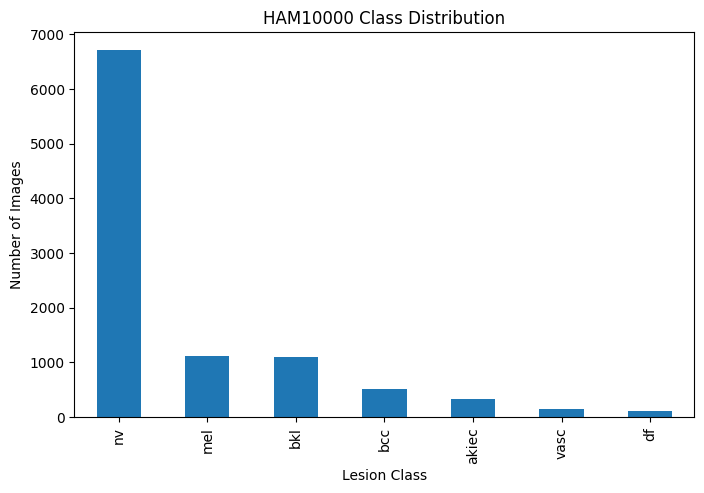

In [3]:
print("Total Images:", len(df))
print("\nClass Distribution:")
print(df["dx"].value_counts())

plt.figure(figsize=(8,5))
df["dx"].value_counts().plot(kind="bar")
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.show()

# 3. Visualize Sample Images

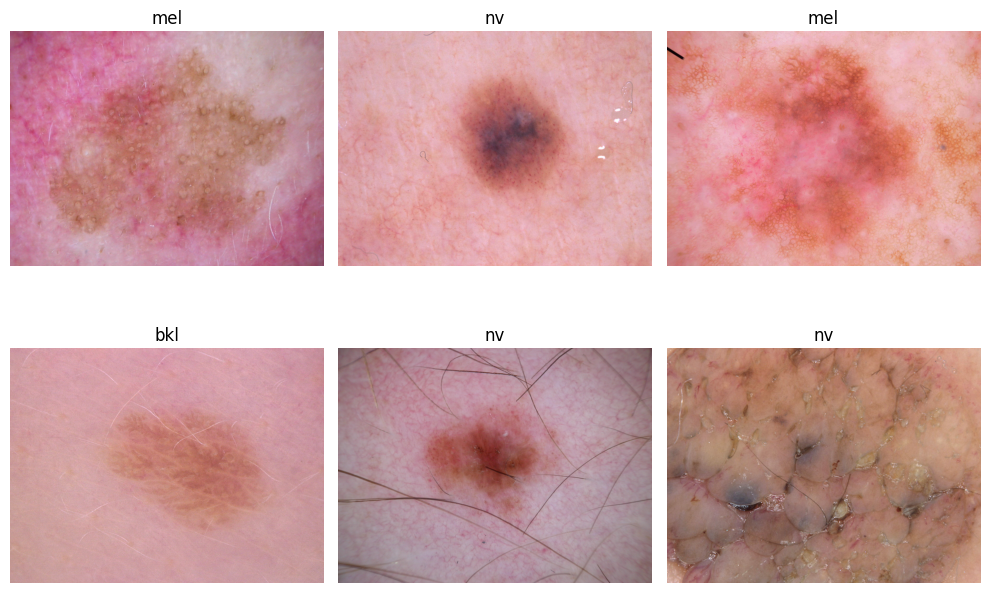

In [4]:
sample_df = df.sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(row["dx"])
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Metadata Preprocessing

In [5]:
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of Classes:", num_classes)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Number of Classes: 7


# 5. Encode Metadata

In [6]:
metadata_df = pd.get_dummies(
    df[["sex", "localization"]],
    drop_first=False
)

metadata_df["age"] = df["age"]

scaler = StandardScaler()
metadata_df["age"] = scaler.fit_transform(metadata_df[["age"]])

metadata_features = metadata_df.values.astype("float32")
metadata_columns = metadata_df.columns.tolist()

print("Metadata Shape:", metadata_features.shape)
print("Metadata Columns:", metadata_columns)

Metadata Shape: (10015, 19)
Metadata Columns: ['sex_female', 'sex_male', 'sex_unknown', 'localization_abdomen', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity', 'age']


# 6. Train / Validation / Test Split

In [7]:
train_df, test_df, train_meta, test_meta = train_test_split(
    df,
    metadata_features,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df, val_df, train_meta, val_meta = train_test_split(
    train_df,
    train_meta,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6409
Validation: 1603
Test: 2003


# 7. Create TensorFlow Datasets

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

def create_image_dataset(dataframe, batch_size=32, shuffle=True):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_image_dataset(train_df, BATCH_SIZE, shuffle=True)
val_ds = create_image_dataset(val_df, BATCH_SIZE, shuffle=False)
test_ds = create_image_dataset(test_df, BATCH_SIZE, shuffle=False)

I0000 00:00:1782660428.142054      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782660428.148339      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# 8. Fusion Dataset

In [9]:
def load_image_with_metadata(path, metadata, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    return {
        "image_input": image,
        "metadata_input": metadata
    }, label

def create_fusion_dataset(dataframe, metadata, batch_size=32, shuffle=True):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, metadata, labels))
    dataset = dataset.map(load_image_with_metadata, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_fusion_ds = create_fusion_dataset(train_df, train_meta, BATCH_SIZE, shuffle=True)
val_fusion_ds = create_fusion_dataset(val_df, val_meta, BATCH_SIZE, shuffle=False)
test_fusion_ds = create_fusion_dataset(test_df, test_meta, BATCH_SIZE, shuffle=False)

# 9. Class Weights

In [10]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(4.380724538619275),
 1: np.float64(2.782891880156318),
 2: np.float64(1.3023775655354604),
 3: np.float64(12.372586872586872),
 4: np.float64(1.2859149277688604),
 5: np.float64(0.2133701767819689),
 6: np.float64(10.061224489795919)}

# 10. Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# 11. Model 1: Custom CNN

In [12]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,

        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10


I0000 00:00:1782660439.060980      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.2835 - loss: 1.8439 - val_accuracy: 0.4329 - val_loss: 1.4947
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.3762 - loss: 1.7434 - val_accuracy: 0.4660 - val_loss: 1.3732
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4361 - loss: 1.6343 - val_accuracy: 0.4978 - val_loss: 1.3310
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.4553 - loss: 1.5190 - val_accuracy: 0.4972 - val_loss: 1.3859
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4785 - loss: 1.4543 - val_accuracy: 0.4635 - val_loss: 1.5928
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4681 - loss: 1.4091 - val_accuracy: 0.4991 - val_loss: 1.2612
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4867 - loss: 1.4040 - val_accuracy: 0.5084 - val_loss: 1.3084
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.4871 - loss: 1.3545 - val_accura

# 12. Model 2: MobileNetV2 Image Only

In [14]:
def build_mobilenet_image_only():
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)

    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

mobilenet_model = build_mobilenet_image_only()
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 1,370,951 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [15]:
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.4355 - loss: 1.5291 - val_accuracy: 0.6843 - val_loss: 1.0888
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.5539 - loss: 1.0723 - val_accuracy: 0.7230 - val_loss: 0.8651
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.6031 - loss: 0.9228 - val_accuracy: 0.7492 - val_loss: 0.7507
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.6572 - loss: 0.8013 - val_accuracy: 0.7374 - val_loss: 0.7391
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.6712 - loss: 0.7437 - val_accuracy: 0.7305 - val_loss: 0.7118
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.6862 - loss: 0.6650 - val_accuracy: 0.7305 - val_loss: 0.7308
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.7124 - loss: 0.5992 - val_accuracy: 0.7274 - val_loss: 0.7295
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.7171 - loss: 0

# 13. Model 3: MobileNetV2 + Metadata Fusion

In [16]:
def build_metadata_fusion_model(metadata_dim):
    image_input = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="image_input"
    )

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    x1 = data_augmentation(image_input)

    x1 = base_model(x1, training=False)

    x1 = layers.GlobalAveragePooling2D()(x1)

    x1 = layers.Dense(128, activation="relu")(x1)

    metadata_input = layers.Input(
        shape=(metadata_dim,),
        name="metadata_input"
    )

    x2 = layers.Dense(64, activation="relu")(metadata_input)

    x2 = layers.Dense(32, activation="relu")(x2)

    combined = layers.Concatenate()([x1, x2])

    combined = layers.Dense(128, activation="relu")(combined)

    combined = layers.Dropout(0.4)(combined)

    output = layers.Dense(
        num_classes,
        activation="softmax"
    )(combined)

    model = models.Model(
        inputs=[image_input, metadata_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

metadata_dim = train_meta.shape[1]

fusion_model = build_metadata_fusion_model(metadata_dim)

fusion_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ sequential[2][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      1,280 │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 7)         │        903 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,446,823 (9.33 MB)

 Trainable params: 1,394,919 (5.32 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [17]:
history_fusion = fusion_model.fit(
    train_fusion_ds,
    validation_data=val_fusion_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 108ms/step - accuracy: 0.4377 - loss: 1.5441 - val_accuracy: 0.7043 - val_loss: 0.9003
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.5673 - loss: 1.1175 - val_accuracy: 0.7187 - val_loss: 0.8475
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.6327 - loss: 0.9327 - val_accuracy: 0.7255 - val_loss: 0.7598
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.6619 - loss: 0.8084 - val_accuracy: 0.7492 - val_loss: 0.7038
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.6917 - loss: 0.7176 - val_accuracy: 0.7361 - val_loss: 0.7235
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.7037 - loss: 0.6556 - val_accuracy: 0.7268 - val_loss: 0.7225
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.7230 - loss: 0.5768 - val_accuracy: 0.7180 - val_loss: 0.7703
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.7561 - loss: 0

# 14. Evaluation Functions

In [18]:
def evaluate_image_model(model, dataset, dataframe, model_name):
    y_true = dataframe["label"].values

    y_pred_prob = model.predict(dataset)

    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{model_name} Results")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    return result, y_pred


def evaluate_fusion_model(model, dataset, dataframe, model_name):
    y_true = dataframe["label"].values

    y_pred_prob = model.predict(dataset)

    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{model_name} Results")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    return result, y_pred

# 15. Run Evaluation

In [19]:
cnn_result, cnn_pred = evaluate_image_model(
    cnn_model,
    test_ds,
    test_df,
    "Custom CNN"
)

mobilenet_result, mobilenet_pred = evaluate_image_model(
    mobilenet_model,
    test_ds,
    test_df,
    "MobileNetV2 Image Only"
)

fusion_result, fusion_pred = evaluate_fusion_model(
    fusion_model,
    test_fusion_ds,
    test_df,
    "MobileNetV2 + Metadata Fusion"
)

results_df = pd.DataFrame([
    cnn_result,
    mobilenet_result,
    fusion_result
])

results_df

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step

Custom CNN Results
Accuracy: 0.4762855716425362
Precision: 0.7455991119117249
Recall: 0.4762855716425362
F1-score: 0.53155510401539

Classification Report:
              precision    recall  f1-score   support

       akiec       0.16      0.49      0.24        65
         bcc       0.33      0.43      0.37       103
         bkl       0.27      0.47      0.34       220
          df       0.06      0.22      0.10        23
         mel       0.26      0.62      0.37       223
          nv       0.99      0.46      0.63      1341
        vasc       0.34      0.54      0.42        28

    accuracy                           0.48      2003
   macro avg       0.34      0.46      0.35      2003
weighted avg       0.75      0.48      0.53      2003

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step

MobileNetV2 Image Only Results
Accuracy: 0.692461308037943
Precision: 0.7843179829225203
Recall: 0.692461308037943
F1-score: 0.716830164950127

Classification Repo

,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.476286,0.745599,0.476286,0.531555
1,MobileNetV2 Image Only,0.692461,0.784318,0.692461,0.716830
2,MobileNetV2 + Metadata Fusion,0.591613,0.808002,0.591613,0.641628


# 16. Save Metrics

In [20]:
os.makedirs("outputs", exist_ok=True)

results_df.to_csv(
    "outputs/metrics.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.476286,0.745599,0.476286,0.531555
1,MobileNetV2 Image Only,0.692461,0.784318,0.692461,0.716830
2,MobileNetV2 + Metadata Fusion,0.591613,0.808002,0.591613,0.641628


# 17. Performance Comparison Graph

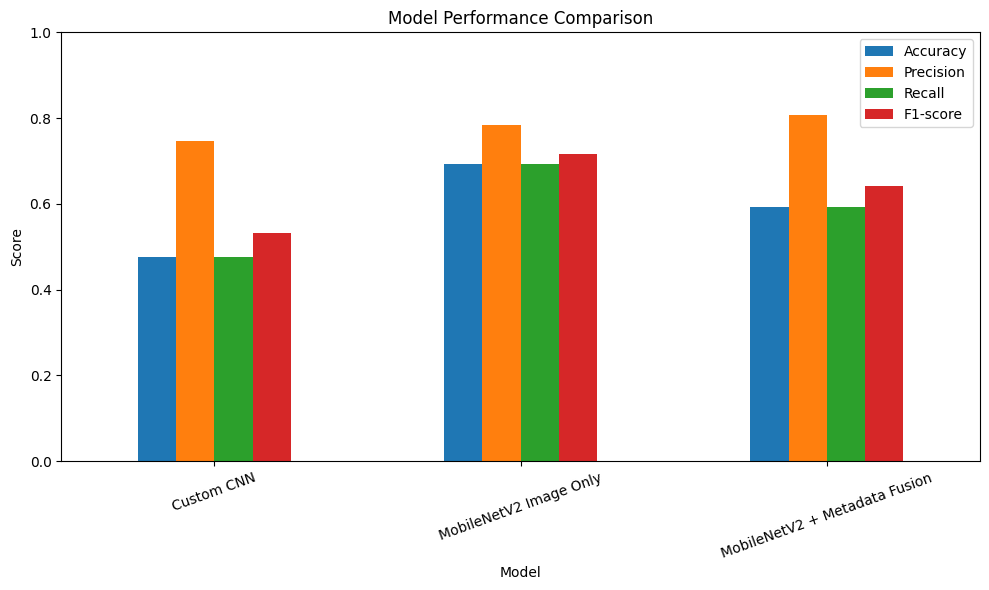

In [21]:
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1-score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/model_comparison.png")
plt.show()

# 18. Confusion Matrix for Best Model

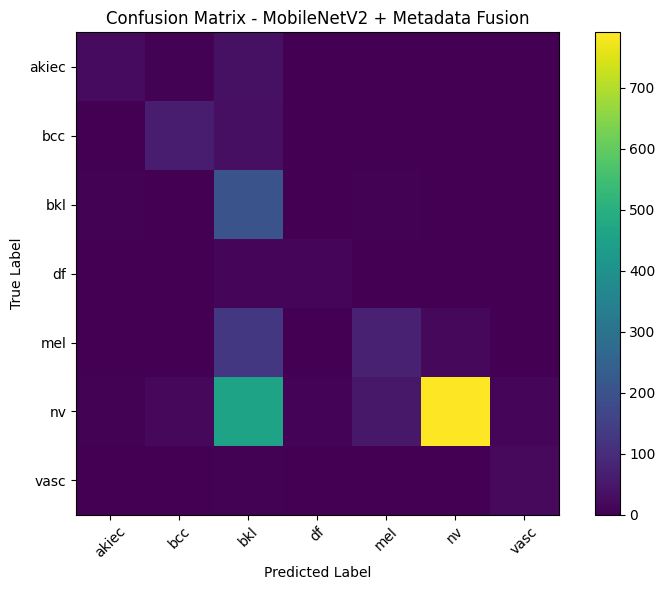

In [22]:
best_pred = fusion_pred

cm = confusion_matrix(
    test_df["label"].values,
    best_pred
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - MobileNetV2 + Metadata Fusion")

plt.colorbar()

plt.xticks(
    np.arange(num_classes),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(num_classes),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("outputs/confusion_matrix.png")

plt.show()

# 19. Training History Plot

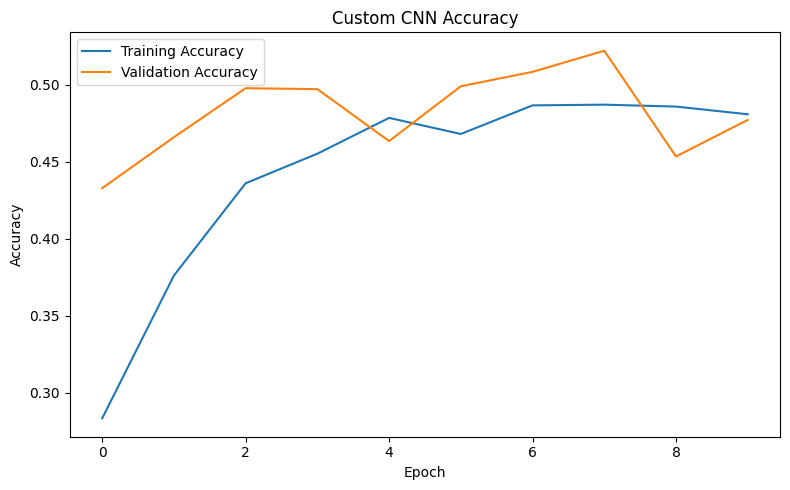

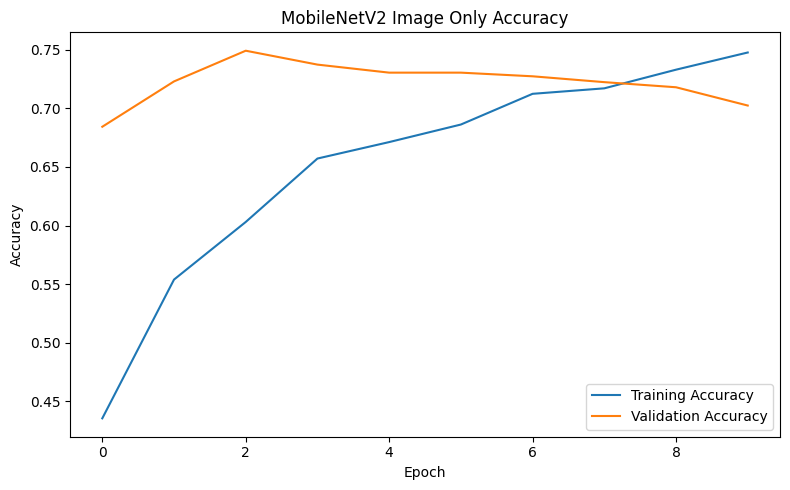

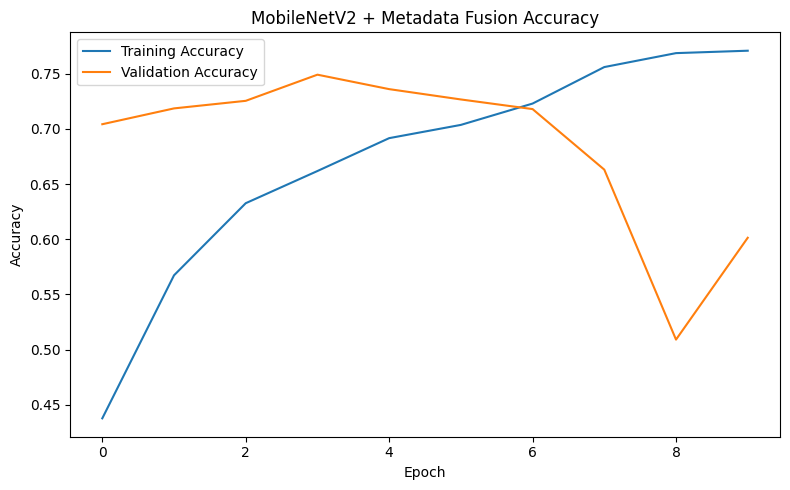

In [23]:
def plot_training_history(history, title, filename):
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(title)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.tight_layout()

    plt.savefig(filename)

    plt.show()


plot_training_history(
    history_cnn,
    "Custom CNN Accuracy",
    "outputs/custom_cnn_accuracy.png"
)

plot_training_history(
    history_mobilenet,
    "MobileNetV2 Image Only Accuracy",
    "outputs/mobilenet_accuracy.png"
)

plot_training_history(
    history_fusion,
    "MobileNetV2 + Metadata Fusion Accuracy",
    "outputs/fusion_accuracy.png"
)

# 20. Save Models for Deployment

In [24]:
os.makedirs("model", exist_ok=True)

# Best for web deployment because it needs only image input
mobilenet_model.save(
    "model/SkinGuard_XAI_Image_Model.keras"
)

# Best research model because it uses image + metadata
fusion_model.save(
    "model/SkinGuard_XAI_Metadata_Fusion_Model.keras"
)

with open("model/class_names.json", "w") as f:
    json.dump(class_names, f)

with open("model/metadata_columns.json", "w") as f:
    json.dump(metadata_columns, f)

print("Models and class names saved successfully.")

Models and class names saved successfully.


# 21. Single Image Prediction Function

In [25]:
# Deployment test

def predict_skin_image(image_path, model, class_names):
    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image_array = np.expand_dims(
        image.astype("float32"),
        axis=0
    )

    image_array = preprocess_input(image_array)

    prediction = model.predict(image_array)

    predicted_index = np.argmax(prediction[0])

    predicted_class = class_names[predicted_index]

    confidence = prediction[0][predicted_index]

    return predicted_class, confidence, image

# 22. Test Single Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


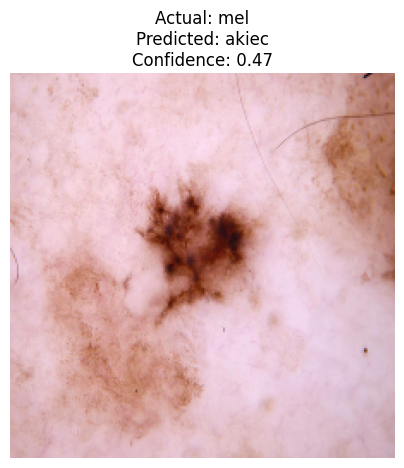

In [26]:
sample_row = test_df.sample(1, random_state=42).iloc[0]

sample_image_path = sample_row["image_path"]

actual_class = sample_row["dx"]

predicted_class, confidence, image = predict_skin_image(
    sample_image_path,
    mobilenet_model,
    class_names
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}"
)

plt.axis("off")

plt.show()

# 23. Save Sample Prediction

In [27]:
prediction_output = pd.DataFrame([
    {
        "image_id": sample_row["image_id"],
        "actual_class": actual_class,
        "predicted_class": predicted_class,
        "confidence": confidence
    }
])

prediction_output.to_csv(
    "outputs/sample_prediction.csv",
    index=False
)

prediction_output

,image_id,actual_class,predicted_class,confidence
0,ISIC_0026847,mel,akiec,0.465064


# 24. Medical Disclaimer

In [28]:
print("""
Medical Disclaimer:
This project is for educational and research purposes only.
It is not a certified medical device.
It should not be used for clinical diagnosis or treatment.
Always consult qualified healthcare professionals for medical advice.
""")


Medical Disclaimer:
This project is for educational and research purposes only.
It is not a certified medical device.
It should not be used for clinical diagnosis or treatment.
Always consult qualified healthcare professionals for medical advice.



In [29]:
import os
import json

os.makedirs("model", exist_ok=True)

mobilenet_model.save(
    "model/SkinGuard_XAI_Image_Model.keras"
)

fusion_model.save(
    "model/SkinGuard_XAI_Metadata_Fusion_Model.keras"
)

with open("model/class_names.json", "w") as f:
    json.dump(class_names, f)

with open("model/metadata_columns.json", "w") as f:
    json.dump(metadata_columns, f)